In [1]:
import numpy as np
import os
import scipy
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.animation import FuncAnimation
import image as img
import cwt2D1T as cwt
%matplotlib ipympl

In [2]:
data_filtered = np.load('./data/comp_filtered.npy')
intensity = np.load('./data/intensity.npy')
comp_data = np.load('./data/comp_data.npy')
mask = np.ones_like(comp_data)
mask[comp_data==0] = np.nan
del comp_data
dx = 3.234
dy = 3.234
dt = 30

## 展示kx-omega功率谱分布

In [ ]:
kx_array = np.linspace(-0.4, 0.4, 80)
ky_array = np.linspace(-0.1, 0.1, 5)
omega_array = np.linspace(0.005, 0.06, 80)
psd = cwt.full_3d_psd(data_filtered, kx_array, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (80, 5, 80))

In [ ]:
psd_st_mean = np.mean(psd[20:40, 60:70, 60:90, ...], axis=(0, 1, 2))
psd_kx_omega = np.trapezoid(psd_st_mean, x=ky_array, axis=1)/cwt.c_psi(1, 2, 4)/16

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(psd_kx_omega.T, cmap='jet', origin='lower', extent=(kx_array[0], kx_array[-1], omega_array[0], omega_array[-1]),norm=LogNorm(vmin=0.0005))
ax.set_xlabel('kx')
ax.set_ylabel('omega')
ax.grid(True, alpha=0.3)
ax.set_aspect('auto')
plt.colorbar(im, ax=ax, label=r'$PSD[Km^3\cdot s^{-1}]$')
# fig.savefig('./fig/psd示例.png', dpi=300)

In [ ]:
plt.close(fig)

## 计算内外传功率
筛选范围：

In [ ]:
kx_array_out = np.linspace(-0.19, -0.05, 15)
kx_array_in = np.linspace(0.1, 0.24, 15)
omega_array = np.linspace(0.014, 0.029, 16)
ky_array = np.linspace(-0.9, 0.9, 15)

In [ ]:
power_out = cwt.full_3d_psd(data_filtered, kx_array_out, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (15, 15, 16))
power_out = np.trapezoid(power_out, x=omega_array, axis=-1)
power_out = np.trapezoid(power_out, x=ky_array, axis=-1)
power_out = np.trapezoid(power_out, x=kx_array_out, axis=-1)*mask

In [ ]:
power_in = cwt.full_3d_psd(data_filtered, kx_array_in, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (15, 15, 16))
power_in = np.trapezoid(power_in, x=omega_array, axis=-1)
power_in = np.trapezoid(power_in, x=ky_array, axis=-1)
power_in = np.trapezoid(power_in, x=kx_array_in, axis=-1)*mask

### 读取电子密度数据，计算能流

In [3]:
import spacepy.pybats as bats
data_path = "./data/shl_var_4_n00032000.out"
data = bats.IdlFile(data_path)
Rs = 961.45/4.46*3.234  # 697.16Mm
r = data['r']
r *= Rs  # Mm
lon = data['lon']
lat = data['lat']
rho = data['Rho']  # g/cm^3
rho = rho[:, 0, :]*1e3 # Kg/m^3，经度0

In [4]:
X, Y = np.meshgrid(np.arange(530, 590), np.arange(250, 370), indexing='ij')
height = np.sqrt((X-310.5)**2 + (Y-310.5)**2) * 3.234
lat_grid = np.arcsin((X-310.5)*3.234/height)/np.pi*180
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (r, lat), rho,
    bounds_error=False,
    fill_value=None
)

points = np.stack([height.ravel(), lat_grid.ravel()], axis=1)

rho_grid = interp(points).reshape(height.shape)

In [12]:
np.min(height-Rs)

np.float64(12.705805808820628)

In [5]:
x_grid = height/Rs
rho_grid = 1.3*1e11*(1/x_grid**2 + 25/x_grid**4 + 300/x_grid**8 + 1500/x_grid**16 + 5796/x_grid**33.9)

In [ ]:
fig, ax = plt.subplots()
ax.imshow(rho_grid, cmap='gray', origin='lower', norm=LogNorm())

In [ ]:
plt.close(fig)

In [41]:
flux_in = power_in * rho_grid[:, : ,None] * 0.15
flux_out = power_out * rho_grid[:, :, None] * 0.44

内外传功率随高度的分布

In [ ]:
fig, ax = plt.subplots()
ax.plot(dx*np.arange(60), np.nanmean(flux_out, axis=(1, 2)), color='blue', label='outflow')
ax.plot(dx*np.arange(60), np.nanmean(flux_in, axis=(1, 2)), color='red', label='inflow')
# ax.plot(dx*np.arange(60), np.nanmean(rho_grid, axis=1), color='red', label='inflow')
ax.set_xlabel('Height [Mm]')
ax.set_ylabel('Power')
ax.legend()

In [ ]:
plt.close(fig)

计算反射率、透射率、耗散率，1代表高高度，2代表低高度

In [ ]:
in_1 = flux_in[1:]
in_2 = flux_in[0:-1]
out_1 = flux_out[1:]
out_2 = flux_out[0:-1]
r = (in_1*out_1 - in_2*out_2)/(in_1**2 - out_2**2)
t = (in_1*in_2 - out_1*out_2)/(in_1**2 - out_2**2)
d = 1 - r - t

In [ ]:
data_list = [r, t, d]
text_list = ['Reflection Rate', 'Transmission Rate', 'Dissipation rate']
im_list = []
title_list = []
fig, axs = plt.subplots(nrows=3, figsize=(8, 12))
for i in range(3):
    data = data_list[i]
    title_text = text_list[i]
    im = axs[i].imshow(data[:, :, 0], origin='lower', cmap='jet', extent=(0, 120*3.234, 0, 59*3.234), vmin=0, vmax=1)
    title = axs[i].set_title(title_text + f'\ntime: {0:03d}s')
    axs[i].set_xlabel(r'$\theta$ direction[Mm]')
    axs[i].set_ylabel('r direction[Mm]')
    im_list.append(im)
    title_list.append(title)
    plt.colorbar(im, ax=axs[i], label=title_text)

def update(frame):
    for i in range(3):
        im_list[i].set_data(data_list[i][:, :, frame])
        title_list[i].set_text(text_list[i] + f'\ntime: {30*frame:03d}s')
    return im_list + title_list

ani = FuncAnimation(fig, update, frames=135, interval=100, blit=True)

In [ ]:
plt.close(fig)

时间平均

In [42]:
in_1 = np.nanmean(flux_in[1:], axis=-1)
in_2 = np.nanmean(flux_in[0:-1], axis=-1)
out_1 = np.nanmean(flux_out[1:], axis=-1)
out_2 = np.nanmean(flux_out[0:-1], axis=-1)
r = (in_1*out_1 - in_2*out_2)/(in_1**2 - out_2**2)
t = (in_1*in_2 - out_1*out_2)/(in_1**2 - out_2**2)
d = 1 - r - t

/tmp/ipykernel_1604258/763364761.py:1: RuntimeWarning: Mean of empty slice
  in_1 = np.nanmean(flux_in[1:], axis=-1)
/tmp/ipykernel_1604258/763364761.py:2: RuntimeWarning: Mean of empty slice
  in_2 = np.nanmean(flux_in[0:-1], axis=-1)
/tmp/ipykernel_1604258/763364761.py:3: RuntimeWarning: Mean of empty slice
  out_1 = np.nanmean(flux_out[1:], axis=-1)
/tmp/ipykernel_1604258/763364761.py:4: RuntimeWarning: Mean of empty slice
  out_2 = np.nanmean(flux_out[0:-1], axis=-1)


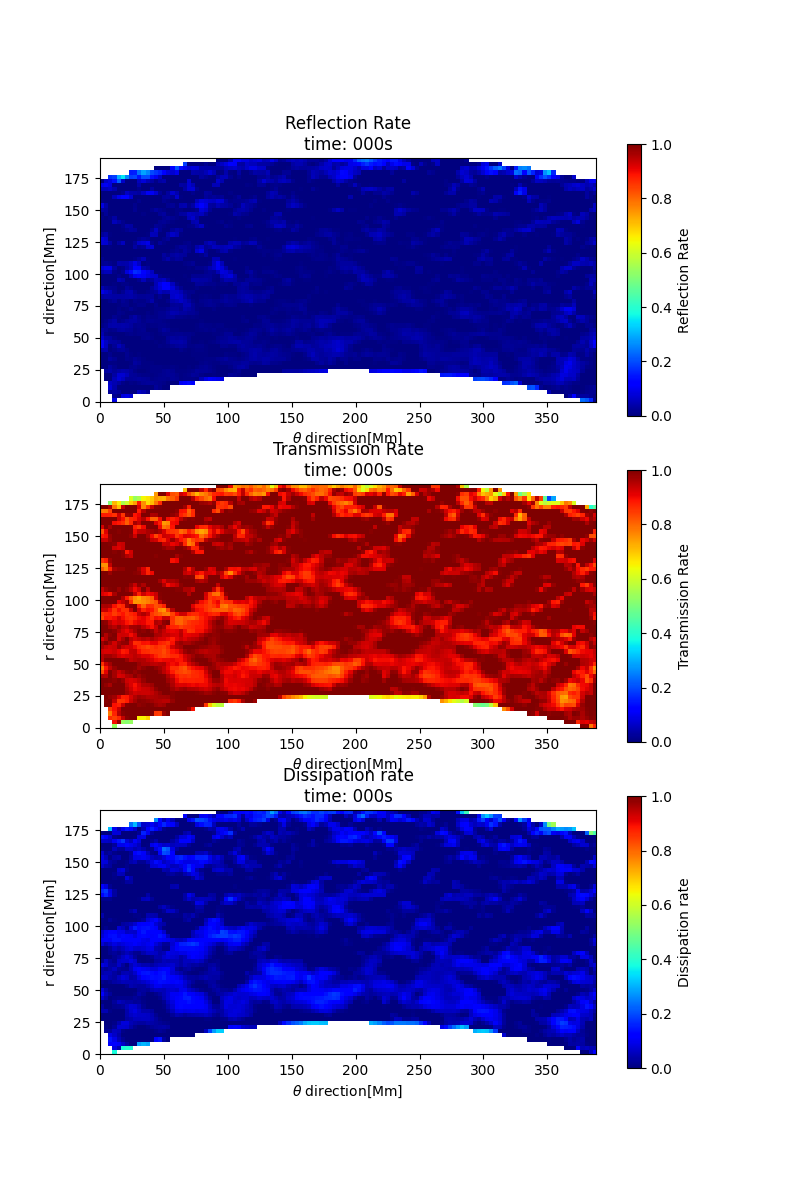

In [43]:
fig, axs = plt.subplots(nrows=3, figsize=(8, 12))
data_list = [r, t, d]
text_list = ['Reflection Rate', 'Transmission Rate', 'Dissipation rate']
for i in range(3):
    data = data_list[i]
    title_text = text_list[i]
    im = axs[i].imshow(data, origin='lower', cmap='jet', extent=(0, 120*3.234, 0, 59*3.234), vmin=0, vmax=1)
    title = axs[i].set_title(title_text + f'\ntime: {0:03d}s')
    axs[i].set_xlabel(r'$\theta$ direction[Mm]')
    axs[i].set_ylabel('r direction[Mm]')
    plt.colorbar(im, ax=axs[i], label=title_text)

In [44]:
plt.close(fig)

角向平均

In [ ]:
in_1 = np.nanmean(flux_in[1:], axis=(1, 2))
in_2 = np.nanmean(flux_in[0:-1], axis=(1, 2))
out_1 = np.nanmean(flux_out[1:], axis=(1, 2))
out_2 = np.nanmean(flux_out[0:-1], axis=(1, 2))
r = (in_1*out_1 - in_2*out_2)/(in_1**2 - out_2**2)
t = (in_1*in_2 - out_1*out_2)/(in_1**2 - out_2**2)
d = 1 - r - t

In [ ]:
fig, ax = plt.subplots()
ax.plot(dx*np.arange(59), r, color='blue', label='Reflection Rate')
ax.plot(dx*np.arange(59), t, color='red', label='Transmission Rate')
ax.plot(dx*np.arange(59), d, color='green', label='Dissipation rate')
ax.set_xlabel('Height [Mm]')
ax.set_ylabel('Power')
ax.legend()

In [ ]:
plt.close(fig)

## 计算重构信号，利用重构信号计算能流
扰动能量密度计算方式：
$\epsilon = \rho \cdot PSD(x, y, t)$

morton文章中能流的计算方式：
$F = 2\rho (v-\bar{v})^2 c_{ph}$

In [ ]:
kx_array_out = np.linspace(-0.19, -0.05, 15)
kx_array_in = np.linspace(0.1, 0.24, 15)
omega_array = np.linspace(0.014, 0.029, 16)
ky_array = np.linspace(-0.9, 0.9, 15)

In [ ]:
w_out = cwt.full_3d_cwt(data_filtered, kx_array_out, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (15, 15, 16))
rec_out = cwt.full_3d_icwt(w_out, kx_array_out, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (14, 14, 15))
del w_out

In [ ]:
w_in = cwt.full_3d_cwt(data_filtered, kx_array_in, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (15, 15, 16))
rec_in = cwt.full_3d_icwt(w_in, kx_array_in, ky_array, omega_array, dx, dy, dt, 1, 2, 4, (14, 14, 15))
del w_in

In [29]:
rec_out =  np.load('./data/rec_out.npy') * mask
rec_in = np.load('./data/rec_in.npy') * mask

In [38]:
# flux_out = np.nanmean((rec_out - np.nanmean(rec_out, axis=2)[:, :, None])**2, axis=2) * rho_grid
# flux_in = np.nanmean((rec_in - np.nanmean(rec_in, axis=2)[:, :, None])**2, axis=2) * rho_grid
flux_out = np.nanmean((data_filtered)**2, axis=2) * rho_grid * 0.44
flux_in = np.nanmean((rec_in)**2, axis=2) * rho_grid * 0.15

/tmp/ipykernel_1604258/3368085440.py:4: RuntimeWarning: Mean of empty slice
  flux_in = np.nanmean((rec_in)**2, axis=2) * rho_grid * 0.15


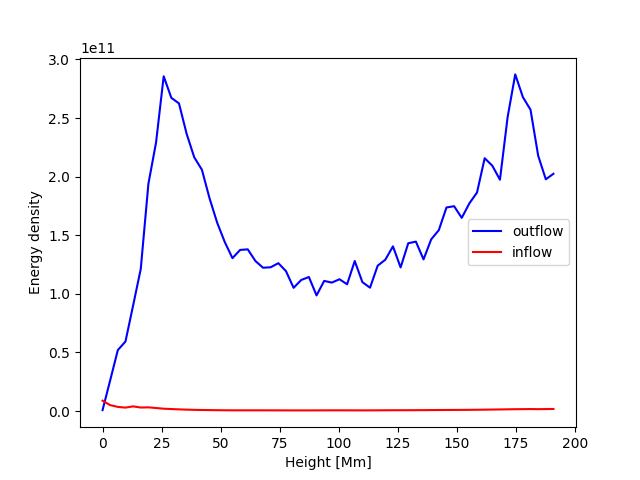

In [39]:
fig, ax = plt.subplots()
ax.plot(dx*np.arange(60), np.nanmean(flux_out, axis=1), color='blue', label='outflow')
ax.plot(dx*np.arange(60), np.nanmean(flux_in, axis=1), color='red', label='inflow')
ax.set_xlabel('Height [Mm]')
ax.set_ylabel('Energy density')
ax.legend()

In [40]:
plt.close(fig)

In [33]:
in_1 = flux_in[1:, :]
in_2 = flux_in[0:-1, :]
out_1 = flux_out[1:, :]
out_2 = flux_out[0:-1, :]
r = (in_1*out_1 - in_2*out_2)/(in_1**2 - out_2**2)
t = (in_1*in_2 - out_1*out_2)/(in_1**2 - out_2**2)
d = 1 - r - t

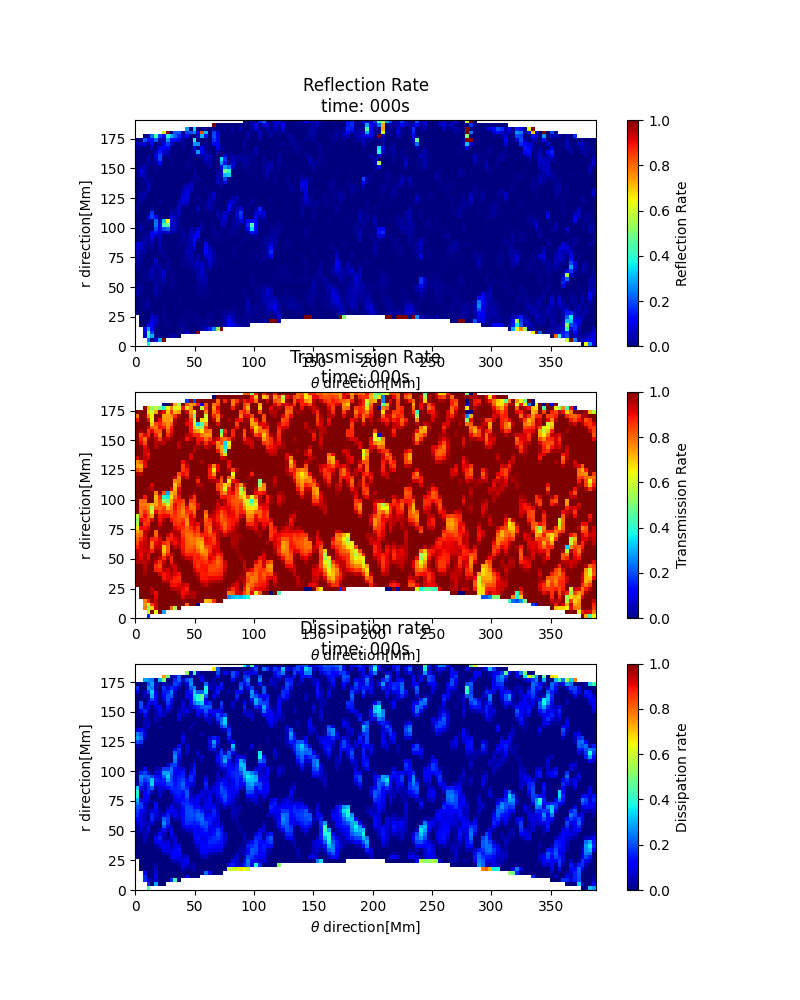

In [34]:
fig, axs = plt.subplots(nrows=3, figsize=(8, 10))
data_list = [r, t, d]
text_list = ['Reflection Rate', 'Transmission Rate', 'Dissipation rate']
for i in range(3):
    data = data_list[i]
    title_text = text_list[i]
    im = axs[i].imshow(data, origin='lower', cmap='jet', extent=(0, 120*3.234, 0, 59*3.234), vmin=0, vmax=1)
    title = axs[i].set_title(title_text + f'\ntime: {0:03d}s')
    axs[i].set_xlabel(r'$\theta$ direction[Mm]')
    axs[i].set_ylabel('r direction[Mm]')
    plt.colorbar(im, ax=axs[i], label=title_text)

In [35]:
plt.close(fig)

In [ ]:
fig, ax = plt.subplots()
ax.imshow(flux_in, origin='lower', cmap='jet', norm=LogNorm())

In [ ]:
plt.close(fig)

Text(0.5, 1.0, '$\\rho$')

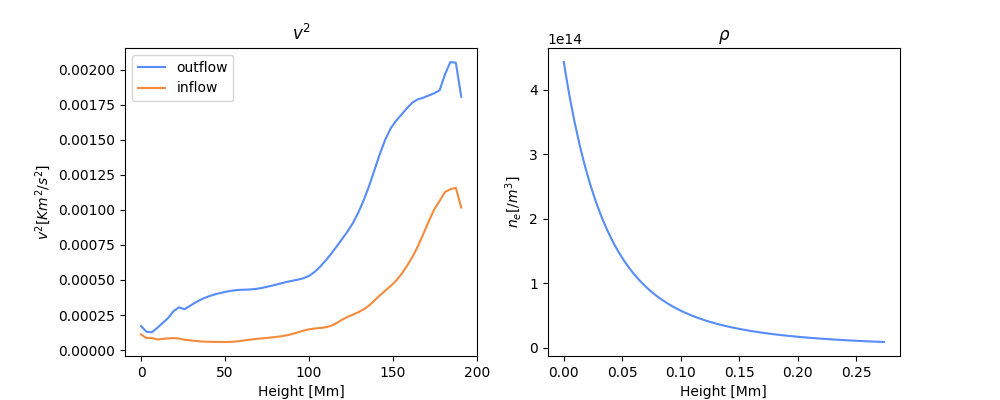

In [36]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
axs[0].plot(dx*np.arange(60), np.nanmean(rec_out**2, axis=(1, 2)), label='outflow')
axs[0].plot(dx*np.arange(60), np.nanmean(rec_in**2, axis=(1, 2)), label='inflow')
axs[0].set_xlabel('Height [Mm]')
axs[0].set_ylabel(r'$v^2 [Km^2/s^2]$')
axs[0].set_title(r'$v^2$')
axs[0].legend()
axs[1].plot(dx*np.arange(60)/Rs, np.nanmean(rho_grid, axis=1))
axs[1].set_xlabel('Height [Mm]')
axs[1].set_ylabel(r'$n_e [/m^3]$')
axs[1].set_title(r'$\rho$')

In [37]:
plt.close(fig)